In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import Splits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# Import Model
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

# Import Metrics
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import root_mean_squared_error as rmse
from scipy.special import huber
from sklearn.metrics import make_scorer, mean_pinball_loss # For Quantile Loss

import datagen as gen

In [ ]:
# Read in the data
df = gen.load_train_data()

## Preprocessing

In [ ]:
# Create a list of all categorical features (needed for CatBoost)
cat_features = ['TYPE_OF_ADMISSION',
    'SEX_CODE',
    'RACE',
    'ETHNICITY',
    'ADMIT_WEEKDAY',
    'EMERGENCY_DEPT_FLAG',
    'CODE_1',
    'CODE_2',
    'CODE_3',
    'CODE_4',
    'CODE_5',
    'CODE_6',
    'CODE_7',
    'CODE_8',
    'CODE_9',
    'CODE_10',
    'CODE_11',
    'CODE_12',
    'CODE_13',
    'CODE_14',
    'CODE_15',
    'CODE_16',
    'CODE_17',
    'CODE_18',
    'CODE_19',
    'CODE_20',
    'CODE_21',
    'PAT_RURAL',
    'PROVIDER_RURAL',
    'QUARTER']

# Clean Categorical Features to make sure everything is a string and no NaN values
df[cat_features] = (
    df[cat_features]
    .fillna("Missing")
    .astype(str)
)

# Create a list of all features and target
features = cat_features.copy()
features.extend(['PAT2PROV_DISTANCE','NUM_CODES','PAT_LATITUDE','PAT_LONGITUDE','PROVIDER_LATITUDE','PROVIDER_LONGITUDE'])

In [4]:
# Extract a set with stratification to do hyperparameter tuning
X_hyp_train, X_hyp_test, y_hyp_train, y_hyp_test = train_test_split(df[features],df.LENGTH_OF_STAY,
                                                    shuffle = True,
                                                    random_state = 1492,
                                                    stratify = df['STRATA'],
                                                   test_size = .975)

# Verifying the size of the tuning train set, wanting to keep over 100,000
X_hyp_train.shape

(140131, 36)

In [7]:
# Find the percentile associated with a 'prolonged' stay of 30 days. This will be the quantile used in Quantile.
quantile = df.loc[df.LENGTH_OF_STAY <= 30].shape[0]/df.shape[0]
quantile

0.987531903035467

## Hyperparameter Tuning

In [5]:
# Hyperparameter Tuning with RMSE
# Third iteration of hyperparameter tuning for all models. Too many values could not be chosen because of length of runtime.
param_grid = {
    "depth": [3, 4, 5, 6, 7], # Common depth values, smaller values considered for boosting methods.
    "learning_rate": [0.001, 0.01, 0.05, .1, .2], # Log scale values (.001,.01,.1) chosen with other options around rates found to be best in previous iterations
    "l2_leaf_reg": [2, 4, 6, 8, 10] # Most erratic of parameters based on previous iterations, so regular intervals chosen
}

# Instantiate Model
rmse_model = CatBoostRegressor(
        iterations=1000,
        bagging_temperature = 0,
        loss_function = "RMSE",
        eval_metric = "RMSE",
        random_seed=80,
        early_stopping_rounds=100,
        verbose=500
    )

# Grid_search instantiated to test each combination of parameters
rmse_grid_search = GridSearchCV(
        estimator = rmse_model,
        param_grid = param_grid,
        scoring = "neg_root_mean_squared_error",
        cv = 3,  # Grid search uses 3 folds for cross-validation
        verbose = 1,
        n_jobs = -1
    )

rmse_grid_search.fit(X_hyp_train, y_hyp_train, cat_features = cat_features)

# Store results of tuning for later use
rmse_results = pd.DataFrame(rmse_grid_search.cv_results_)
rmse_results.to_csv("rmse_grid_search_results.csv", index=False)

Fitting 3 folds for each of 125 candidates, totalling 375 fits
0:	learn: 11.4118306	total: 86.8ms	remaining: 1m 26s
500:	learn: 8.3560095	total: 10.5s	remaining: 10.5s
999:	learn: 7.7974661	total: 20.3s	remaining: 0us


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre..., verbose=500)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [3, 4, ...], 'l2_leaf_reg': [2, 4, ...], 'learning_rate': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

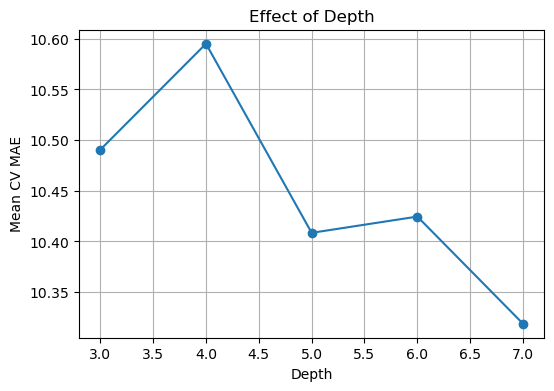

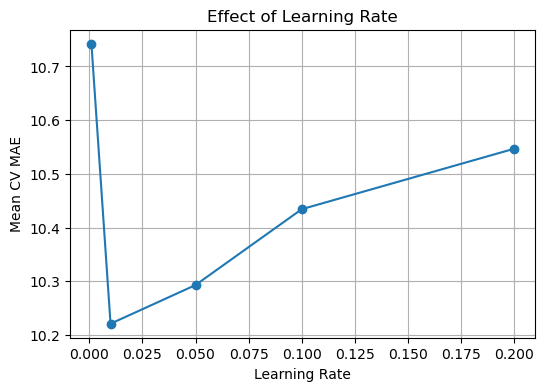

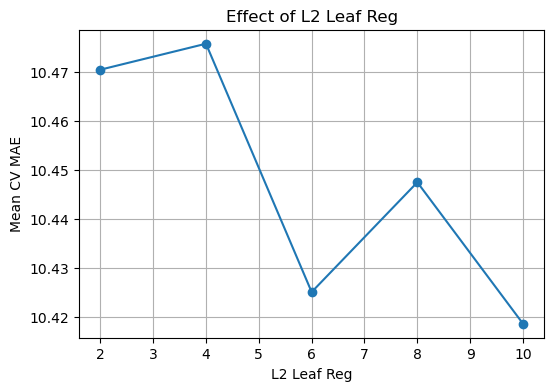

In [8]:
# Visuals for Hyperparameter Tuning on RMSE model

parameters = [
    "depth",
    "learning_rate",
    "l2_leaf_reg"
]

for param in parameters:
    scores = (
        rmse_results.groupby(f"param_{param}")["mean_test_score"]
        .mean()
    )

    plt.figure(figsize=(6,4))
    plt.plot(scores.index, -scores.values, marker="o")   # Negate to show MAE instead of -MAE
    plt.xlabel(param.replace("_", " ").title())
    plt.ylabel("Mean CV MAE")
    plt.title(f"Effect of {param.replace('_', ' ').title()}")
    plt.grid(True)
    plt.show()

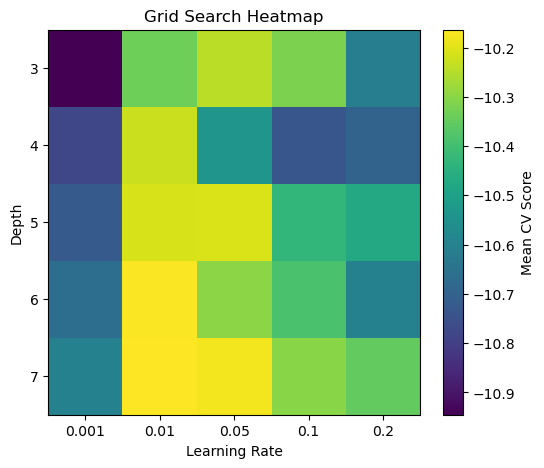

In [11]:
# Heatmap for Hyperparameter Tuning for RMSE model (Depth vs Learning Rate)
pivot = rmse_results.pivot_table(
    values="mean_test_score",
    index="param_depth",
    columns="param_learning_rate"
)

plt.figure(figsize=(6,5))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Mean CV Score")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Learning Rate")
plt.ylabel("Depth")
plt.title("Grid Search Heatmap")
plt.show()

In [5]:
# Hyperparameter Tuning with MAE
# Third iteration of hyperparameter tuning for all models. Too many values could not be chosen because of length of runtime.
param_grid = {
    "depth": [3, 4, 5, 6, 7], # Common depth values, smaller values considered for boosting methods.
    "learning_rate": [0.001, 0.01, 0.05, .1, .2], # Log scale values (.001,.01,.1) chosen with other options around rates found to be best in previous iterations
    "l2_leaf_reg": [2, 4, 6, 8, 10] # Most erratic of parameters based on previous iterations, so regular intervals chosen
}
    
# Instantiate Model
model = CatBoostRegressor(
        iterations=1000,
        loss_function = "MAE",
        eval_metric = "MAE",
        random_seed=800,
        early_stopping_rounds=100,
        verbose=500
    )

# Grid_search instantiated to test each combination of parameters
mae_grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring = "neg_mean_absolute_error",
        cv = 3,  # Grid search uses 3 folds for cross-validation
        verbose = 2,
        n_jobs = -1
    )

mae_grid_search.fit(X_hyp_train, y_hyp_train, cat_features = cat_features)

# Store results of tuning for later use
mae_results = pd.DataFrame(mae_grid_search.cv_results_)
mae_results.to_csv("mae_grid_search_results.csv", index=False)

Fitting 3 folds for each of 125 candidates, totalling 375 fits
0:	learn: 3.3020136	total: 114ms	remaining: 1m 53s
500:	learn: 2.7299102	total: 13.4s	remaining: 13.3s
999:	learn: 2.6827537	total: 26.2s	remaining: 0us


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre..., verbose=500)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [3, 4, ...], 'l2_leaf_reg': [2, 4, ...], 'learning_rate': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

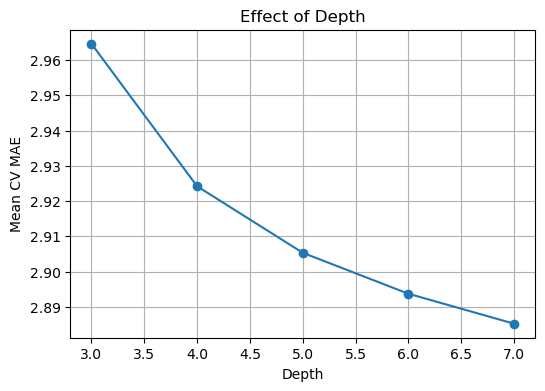

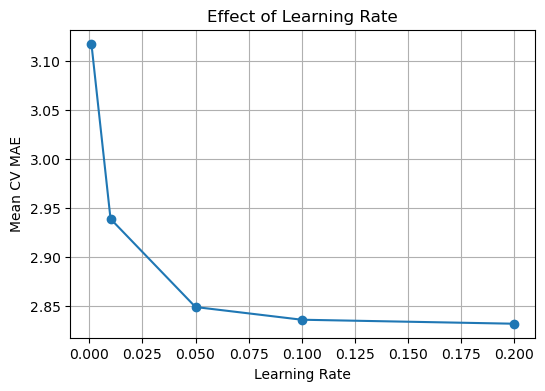

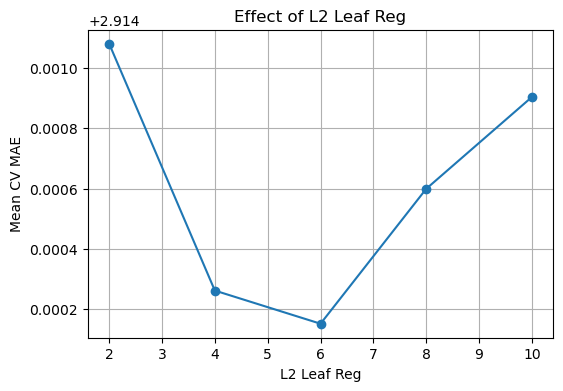

In [7]:
# Visuals for Hyperparameter Tuning on MAE model
parameters = [
    "depth",
    "learning_rate",
    "l2_leaf_reg"
]

mae_results = pd.DataFrame(mae_grid_search.cv_results_)

for param in parameters:
    scores = (
        mae_results.groupby(f"param_{param}")["mean_test_score"]
        .mean()
    )

    plt.figure(figsize=(6,4))
    plt.plot(scores.index, -scores.values, marker="o")   # Negate to show MAE instead of -MAE
    plt.xlabel(param.replace("_", " ").title())
    plt.ylabel("Mean CV MAE")
    plt.title(f"Effect of {param.replace('_', ' ').title()}")
    plt.grid(True)
    plt.show()

In [9]:
# Hyperparameter Tuning with Quantile (alpha = .9875)
# Third iteration of hyperparameter tuning for all models. Too many values could not be chosen because of length of runtime.
param_grid = {
    "depth": [3, 4, 5, 6, 7], # Common depth values, smaller values considered for boosting methods.
    "learning_rate": [0.001, 0.01, 0.05, .1, .2], # Log scale values (.001,.01,.1) chosen with other options around rates found to be best in previous iterations
    "l2_leaf_reg": [2, 4, 6, 8, 10] # Most erratic of parameters based on previous iterations, so regular intervals chosen
}
    
# Instantiate Model
quan_model = CatBoostRegressor(
        iterations=1000,
        bagging_temperature = 0,
        loss_function = "Quantile:alpha=0.987531903035467",
        eval_metric = "Quantile:alpha=0.987531903035467",
        random_seed=42,
        early_stopping_rounds=100,
        verbose=500
    )

# Grid_search instantiated to test each combination of parameters
quan_grid_search = GridSearchCV(
        estimator = quan_model,
        param_grid = param_grid,
        scoring=make_scorer(
            mean_pinball_loss,
            alpha=0.987531903035467,
            greater_is_better=False
            ), #Scorer constructed for Quantile using mean_pinball_loss
        cv = 3,  # Grid search uses 3 folds for cross-validation
        verbose = 2,
        n_jobs = 1
    )

quan_grid_search.fit(X_hyp_train, y_hyp_train, cat_features = cat_features)

# Store results of tuning for later use
quan_results = pd.DataFrame(quan_grid_search.cv_results_)
quan_results.to_csv("quan_grid_search_results.csv", index=False)

Fitting 3 folds for each of 125 candidates, totalling 375 fits
0:	learn: 0.6938819	total: 13.7ms	remaining: 13.7s
500:	learn: 0.5983440	total: 3.87s	remaining: 3.85s
999:	learn: 0.5487858	total: 7.51s	remaining: 0us
[CV] END ........depth=3, l2_leaf_reg=2, learning_rate=0.001; total time=   8.1s
0:	learn: 0.6954883	total: 9.28ms	remaining: 9.27s
500:	learn: 0.6027320	total: 3.8s	remaining: 3.78s
999:	learn: 0.5556883	total: 7.63s	remaining: 0us
[CV] END ........depth=3, l2_leaf_reg=2, learning_rate=0.001; total time=   8.2s
0:	learn: 0.6780039	total: 10.1ms	remaining: 10s
500:	learn: 0.5884881	total: 3.65s	remaining: 3.64s
999:	learn: 0.5422706	total: 7.51s	remaining: 0us
[CV] END ........depth=3, l2_leaf_reg=2, learning_rate=0.001; total time=   8.1s
0:	learn: 0.6897929	total: 11ms	remaining: 11s
500:	learn: 0.4483747	total: 3.86s	remaining: 3.84s
999:	learn: 0.4278094	total: 7.84s	remaining: 0us
[CV] END .........depth=3, l2_leaf_reg=2, learning_rate=0.01; total time=   8.4s
0:	learn

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre..., verbose=500)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [3, 4, ...], 'l2_leaf_reg': [2, 4, ...], 'learning_rate': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...7531903035467)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

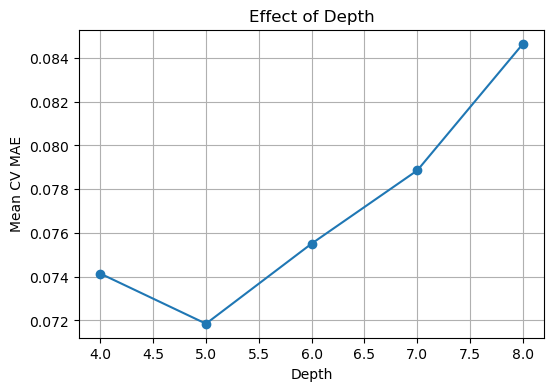

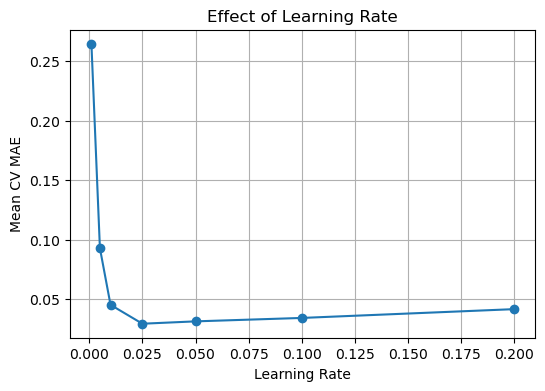

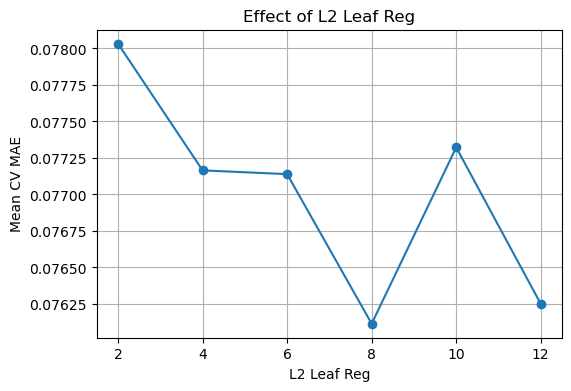

In [43]:
# Visuals for Hyperparameter Tuning on Quantile model

parameters = [
    "depth",
    "learning_rate",
    "l2_leaf_reg"
]

quan_results = pd.DataFrame(quan_grid_search.cv_results_)

for param in parameters:
    scores = (
        quan_results.groupby(f"param_{param}")["mean_test_score"]
        .mean()
    )

    plt.figure(figsize=(6,4))
    plt.plot(scores.index, -scores.values, marker="o")   # Negate to show MAE instead of -MAE
    plt.xlabel(param.replace("_", " ").title())
    plt.ylabel("Mean CV MAE")
    plt.title(f"Effect of {param.replace('_', ' ').title()}")
    plt.grid(True)
    plt.show()

In [ ]:
# Hyperparameter Tuning with Huber (delta = 2.0)
# Third iteration of hyperparameter tuning for all models. Too many values could not be chosen because of length of runtime.
param_grid = {
    "depth": [3, 4, 5, 6, 7], # Common depth values, smaller values considered for boosting methods.
    "learning_rate": [0.001, 0.01, 0.05, .1, .2], # Log scale values (.001,.01,.1) chosen with other options around rates found to be best in previous iterations
    "l2_leaf_reg": [2, 4, 6, 8, 10] # Most erratic of parameters based on previous iterations, so regular intervals chosen
}

#Huber Loss and Scoring function created, but struggled to fit model without optimized preset scoring metrics, MAE used instead.

# def huber_loss(y_true, y_pred, delta=2.0):
#     error = y_true - y_pred
#     is_small = np.abs(error) <= delta

#     squared = 0.5 * error**2
#     linear = delta * (np.abs(error) - 0.5 * delta)

#     return np.mean(np.where(is_small, squared, linear))

# huber_scorer = make_scorer(
#     huber_loss,
#     delta=2.0,
#     greater_is_better=False)
    
# Instantiate Model
model = CatBoostRegressor(
        iterations=1000,
        bagging_temperature = 0,
        loss_function = "MAE",
        eval_metric = "MAE",
        random_seed=22,
        early_stopping_rounds=100,
        verbose=50
    )

huber_grid_search = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring = "neg_mean_absolute_error",
        cv = 3,  # Grid search uses 3 folds for cross-validation
        verbose = 1,
        n_jobs = 1
    )

huber_grid_search.fit(X_hyp_train, y_hyp_train, cat_features = cat_features)

# Store results of tuning for later use
huber_results = pd.DataFrame(huber_grid_search.cv_results_)
huber_results.to_csv("huber_grid_search_results.csv", index=False)

## Run Models on Training Set

In [5]:
# Do a train_test_split on the data, with stratification, STRATA is column created for this stratification
X_train, X_test, y_train, y_test = train_test_split(df[features],df.LENGTH_OF_STAY,
                                                    shuffle = True,
                                                    random_state = 2222,
                                                    stratify = df['STRATA'],
                                                   test_size = .2)

# Create the StratifiedKFold
strata_train = df.loc[X_train.index, 'STRATA']

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2222
)

In [11]:
# Run the models for each metric on the train set, recording each metric.
# Define Huber Loss Function for Huber metric
def huber_loss(y_true, y_pred, delta=2.0):
    error = y_true - y_pred
    is_small = np.abs(error) <= delta

    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5 * delta)

    return np.mean(np.where(is_small, squared, linear))

# Dictionary defining different metrics and tuned hyperparameters [bagging_temperature, depth, l2_leaf_reg, learning_rate]
# bagging_temperature is from previous iterations of tuning, and always came out to be 0. 
# Huber model showed very poor results and was omitted in later iterations
metrics = {"RMSE" : [0,7,10,0.05],
           "MAE": [0,7,10,0.05],
           # "Huber:delta=2.0": [0,8,10,0.01],
           "Quantile:alpha=0.987531903035467": [0,5,8,0.2]}

# Dataframe used to collect mean metric scores for each model for comparison purposes
scores = pd.DataFrame(
    0.0,
    index=["RMSE", "MAE", "Quantile"],
    columns=["RMSE", "MAE", "Huber", "Quantile"]
)

row_names = {
    "RMSE": "RMSE",
    "MAE": "MAE",
    # "Huber:delta=2.0": "Huber",
    "Quantile:alpha=0.987531903035467": "Quantile"
}

for metric,params in metrics.items():
    fold_rmse = []
    fold_mae = []
    fold_huber = []
    fold_quantile = []
    # Fit the model for each fold
    
    print(f"\nTraining {metric} model...")
    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, strata_train)):
        X_tr = X_train.iloc[train_idx].copy()
        X_val = X_train.iloc[valid_idx].copy()
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        # Instantiate Model
        model = CatBoostRegressor(
            bagging_temperature = params[0], #Tuned Hyperparameter 1
            depth=params[1], #Tuned Hyperparameter 2
            l2_leaf_reg=params[2], #Tuned Hyperparameter 3
            learning_rate=params[3], #Tuned Hyperparameter 4
            iterations=3000,
            loss_function=metric, # metrics looped through 4 options
            eval_metric=metric,
            random_seed=1987,
            early_stopping_rounds=100,
            verbose=500
        )

        model.fit(X_tr,
            y_tr,

                  cat_features = cat_features,
            eval_set = (X_val, y_val),
            use_best_model=True)

        # Find predictions and store metrics 
        preds = model.predict(X_val)
    
        rmse_pred = rmse(y_val,preds)
        mae_pred = mae(y_val,preds)
        quantile_pred = mean_pinball_loss(
            y_val,
            preds,
            alpha=0.987531903035467
        )

        huber_pred = huber_loss(y_val, preds, delta=2.0)

        fold_rmse.append(rmse_pred)
        fold_mae.append(mae_pred)
        fold_huber.append(huber_pred)
        fold_quantile.append(quantile_pred)

        print(
        f"{metric} | Fold {fold+1}/{skf.get_n_splits()} | "
        f"RMSE={rmse_pred:.3f}, "
        f"MAE={mae_pred:.3f}, "
        f"Huber={huber_pred:.3f}, "
        f"Quantile={quantile_pred:.5f}"
        )

    row = row_names[metric]
    
    scores.loc[row, "RMSE"] = np.mean(fold_rmse)
    scores.loc[row, "MAE"] = np.mean(fold_mae)
    scores.loc[row, "Huber"] = np.mean(fold_huber)
    scores.loc[row, "Quantile"] = np.mean(fold_quantile)

    print(f"Finished {metric} model.\n")


Training RMSE model...
0:	learn: 14.4529964	test: 16.3717746	best: 16.3717746 (0)	total: 686ms	remaining: 34m 18s
500:	learn: 12.5166103	test: 15.1729707	best: 15.1729698 (499)	total: 4m 4s	remaining: 20m 19s
1000:	learn: 12.1504163	test: 15.1088399	best: 15.1088399 (1000)	total: 7m 59s	remaining: 15m 58s
1500:	learn: 11.8323888	test: 15.0683706	best: 15.0683049 (1497)	total: 11m 49s	remaining: 11m 48s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 15.0259652
bestIteration = 1875

Shrink model to first 1876 iterations.
RMSE | Fold 1/5 | RMSE=15.026, MAE=3.068, Huber=4.588, Quantile=1.52953
0:	learn: 15.1379976	test: 13.6833439	best: 13.6833439 (0)	total: 718ms	remaining: 35m 53s
500:	learn: 13.3735382	test: 12.0209151	best: 12.0208963 (499)	total: 4m 9s	remaining: 20m 46s
1000:	learn: 12.9988859	test: 11.9364784	best: 11.9358150 (968)	total: 7m 49s	remaining: 15m 38s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 11.93069813
bestIteration = 1036

In [12]:
scores

,RMSE,MAE,Huber,Quantile
RMSE,13.196365,3.084952,4.618177,1.540544
MAE,13.792588,2.750064,4.138255,2.040496
Quantile,29.443069,17.554432,33.130136,0.388806


## Run Best Model(s) on Full Training Set and Evaluate on Test Set
Used to Compare to other models

RMSE and MAE both chosen because of quality of MAE, Huber, and Quantile metrics. 

In [61]:
# Run the MAE model on the full set and record results and feature importance
def huber_loss(y_true, y_pred, delta=0.5):
    error = y_true - y_pred
    is_small = np.abs(error) <= delta

    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5 * delta)

    return np.mean(np.where(is_small, squared, linear))
# Instantiate Model
full_mae_model = CatBoostRegressor(
    bagging_temperature = 0, #Tuned Hyperparameter 1
    depth=7, #Tuned Hyperparameter 2
    l2_leaf_reg=10, #Tuned Hyperparameter 3
    learning_rate=0.05, #Tuned Hyperparameter 4
    iterations=3000,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=1322,
    early_stopping_rounds=100,
    verbose=100
)

full_mae_model.fit(X_train,
    y_train,
    cat_features = cat_features,
    eval_set = (X_test, y_test),
    use_best_model=True)

# Find predictions and store rmses  
preds = full_mae_model.predict(X_test)

rmse_pred = rmse(y_test,preds)
mae_pred = mae(y_test,preds)
quantile_pred = mean_pinball_loss(
    y_test,
    preds,
    alpha=0.987531903035467
)

huber1_pred = huber_loss(y_test, preds, delta=0.5)
huber2_pred = huber_loss(y_test, preds, delta=2.0)


print(
f"MAE | "
f"RMSE={rmse_pred:.3f}, "
f"MAE={mae_pred:.3f}, "
f"Huber=0.5={huber1_pred:.3f}, "
f"Huber=2.0={huber2_pred:.3f}, "
f"Quantile={quantile_pred:.5f}"
)


0:	learn: 3.3050242	test: 3.3023136	best: 3.3023136 (0)	total: 1.7s	remaining: 1h 24m 55s
100:	learn: 2.8859642	test: 2.8824804	best: 2.8824804 (100)	total: 1m 35s	remaining: 45m 53s
200:	learn: 2.8437860	test: 2.8410677	best: 2.8410677 (200)	total: 3m 7s	remaining: 43m 35s
300:	learn: 2.8157370	test: 2.8132428	best: 2.8132428 (300)	total: 4m 46s	remaining: 42m 50s
400:	learn: 2.7951563	test: 2.7934546	best: 2.7934546 (400)	total: 6m 27s	remaining: 41m 49s
500:	learn: 2.7795701	test: 2.7784836	best: 2.7784836 (500)	total: 8m	remaining: 39m 58s
600:	learn: 2.7732315	test: 2.7725169	best: 2.7725169 (600)	total: 9m 38s	remaining: 38m 30s
700:	learn: 2.7657937	test: 2.7654299	best: 2.7654299 (700)	total: 11m 12s	remaining: 36m 46s
800:	learn: 2.7595393	test: 2.7596818	best: 2.7596818 (800)	total: 12m 47s	remaining: 35m 7s
900:	learn: 2.7533262	test: 2.7543710	best: 2.7543710 (900)	total: 14m 22s	remaining: 33m 29s
1000:	learn: 2.7496142	test: 2.7509961	best: 2.7509961 (1000)	total: 15m 54s

In [6]:
# Run the RMSE model on the full set and record results and feature importance
def huber_loss(y_true, y_pred, delta=2.0):
    error = y_true - y_pred
    is_small = np.abs(error) <= delta

    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5 * delta)

    return np.mean(np.where(is_small, squared, linear))
# Instantiate Model
full_rmse_model = CatBoostRegressor(
    bagging_temperature = 0, #Tuned Hyperparameter 1
    depth=7, #Tuned Hyperparameter 2
    l2_leaf_reg=10, #Tuned Hyperparameter 3
    learning_rate=0.05, #Tuned Hyperparameter 4
    iterations=2000,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=2213,
    early_stopping_rounds=100,
    verbose=100
)

full_rmse_model.fit(X_train,
    y_train,
    cat_features = cat_features,
    eval_set = (X_test, y_test),              
    use_best_model=True)

# Find predictions and store metrics 
preds = full_rmse_model.predict(X_test)

rmse_pred = rmse(y_test,preds)
mae_pred = mae(y_test,preds)
quantile_pred = mean_pinball_loss(
    y_test,
    preds,
    alpha=0.987531903035467
)

huber_pred = huber_loss(y_test, preds, delta=2.0)


print(
f"RMSE | "
f"RMSE={rmse_pred:.3f}, "
f"MAE={mae_pred:.3f}, "
f"Huber=2.0={huber_pred:.3f}, "
f"Quantile={quantile_pred:.5f}"
)


0:	learn: 14.8591868	test: 15.5334056	best: 15.5334056 (0)	total: 922ms	remaining: 30m 42s
100:	learn: 13.6482850	test: 14.3763521	best: 14.3763521 (100)	total: 1m 7s	remaining: 21m 16s
200:	learn: 13.4142421	test: 14.1602298	best: 14.1602298 (200)	total: 2m 13s	remaining: 19m 53s
300:	learn: 13.2504403	test: 14.0301659	best: 14.0298247 (299)	total: 3m 18s	remaining: 18m 41s
400:	learn: 13.1305678	test: 13.9795108	best: 13.9795108 (400)	total: 4m 24s	remaining: 17m 36s
500:	learn: 13.0283932	test: 13.9542484	best: 13.9532462 (497)	total: 5m 29s	remaining: 16m 26s
600:	learn: 12.9326270	test: 13.9269906	best: 13.9268435 (597)	total: 6m 32s	remaining: 15m 13s
700:	learn: 12.8679726	test: 13.9117301	best: 13.9117301 (700)	total: 7m 34s	remaining: 14m 1s
800:	learn: 12.8320284	test: 13.8985978	best: 13.8983344 (791)	total: 8m 35s	remaining: 12m 52s
900:	learn: 12.7946610	test: 13.8902405	best: 13.8900257 (888)	total: 9m 40s	remaining: 11m 48s
1000:	learn: 12.7541969	test: 13.8881644	best: 

In [ ]:
# Feature Importance for RMSE model
importance_df = pd.DataFrame({
    "Feature": X_train[features].columns,
    "Importance": full_rmse_model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 12))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

# Largest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

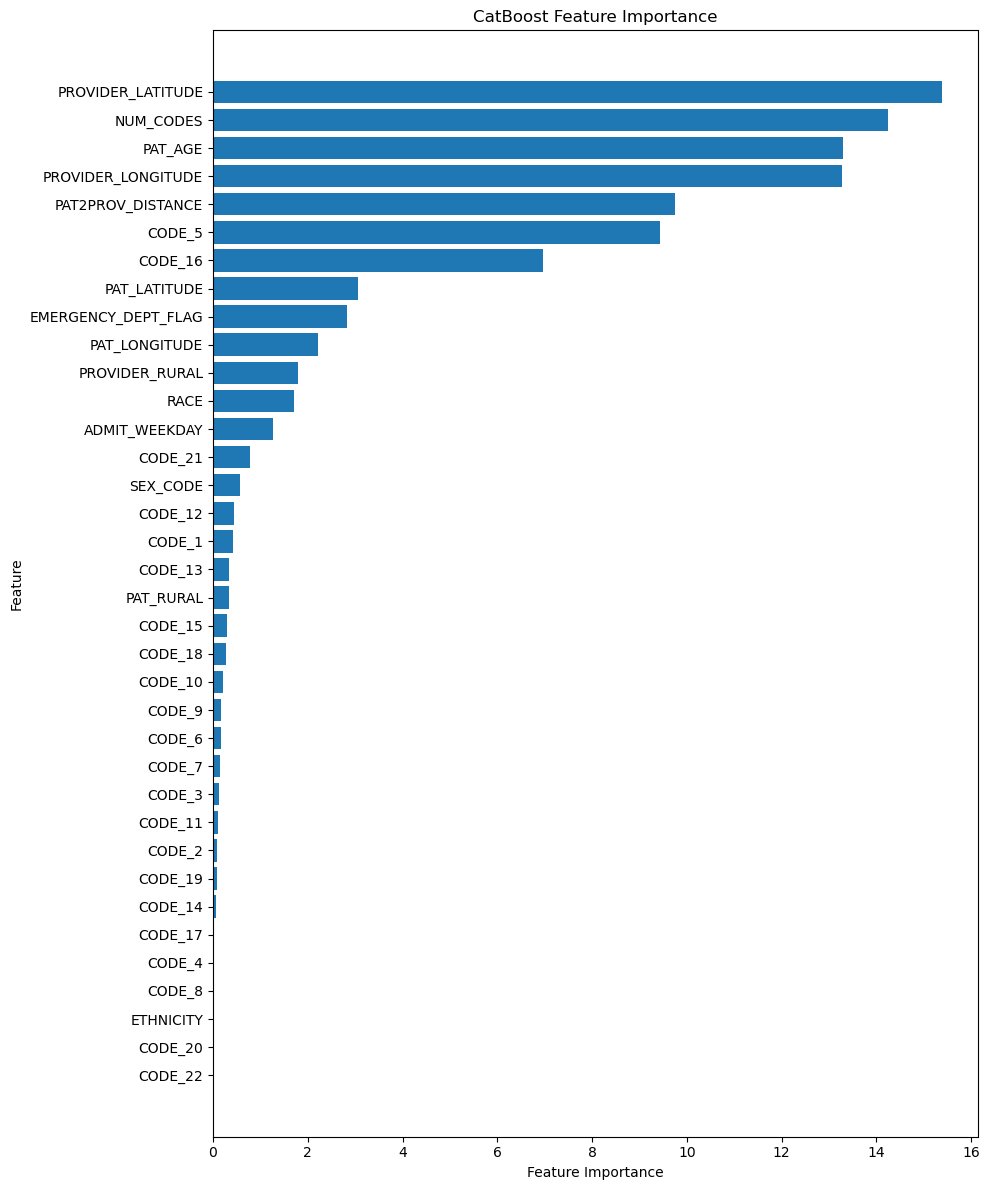

In [8]:
plt.figure(figsize=(10, 12))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

# Largest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()